# Task 1: Exploring and Visualizing the Iris Dataset
**DevelopersHub Corporation – Data Science & Analytics Internship**

## Introduction & Problem Statement
The goal of this task is to understand how to load, explore, and visualize a real-world dataset.
We use the classic **Iris Dataset**, which contains measurements of 150 iris flowers from 3 species:
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Each sample has 4 features: sepal length, sepal width, petal length, and petal width.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Dataset Loading & Understanding

In [2]:
# Load the Iris dataset using seaborn
df = sns.load_dataset('iris')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


Dataset loaded successfully!
Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Dataset info
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Basic Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTarget classes (species): {df['species'].unique()}")
print(f"Class distribution:\n{df['species'].value_counts()}")


Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Target classes (species): ['setosa' 'versicolor' 'virginica']
Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

### Scatter Plot – Relationship Between Variables

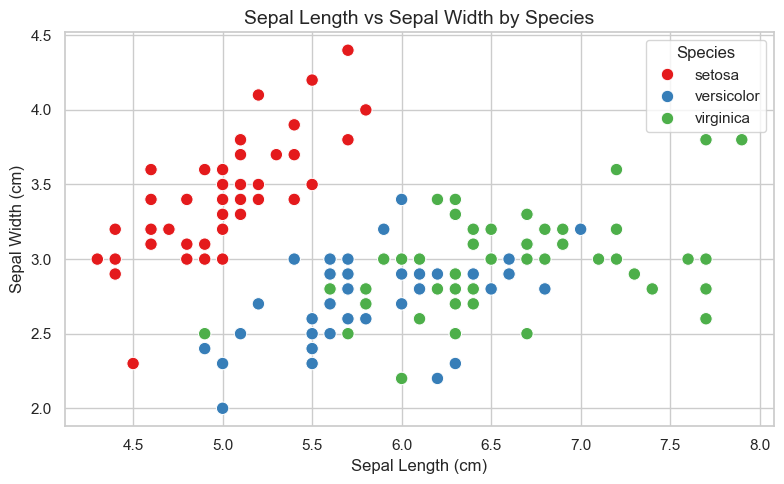

Observation: Setosa is clearly separated from the other two species in sepal dimensions.


In [5]:
# Scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', palette='Set1', s=80)
plt.title('Sepal Length vs Sepal Width by Species', fontsize=14)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()

plt.show()
print("Observation: Setosa is clearly separated from the other two species in sepal dimensions.")


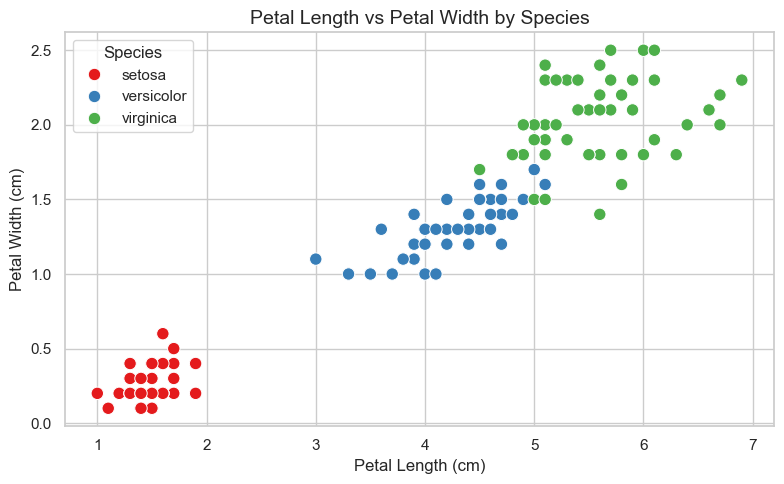

Observation: Petal dimensions show very clear separation between all 3 species.


In [6]:
# Scatter plot: Petal Length vs Petal Width
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set1', s=80)
plt.title('Petal Length vs Petal Width by Species', fontsize=14)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()

plt.show()
print("Observation: Petal dimensions show very clear separation between all 3 species.")


### Histogram – Feature Distribution

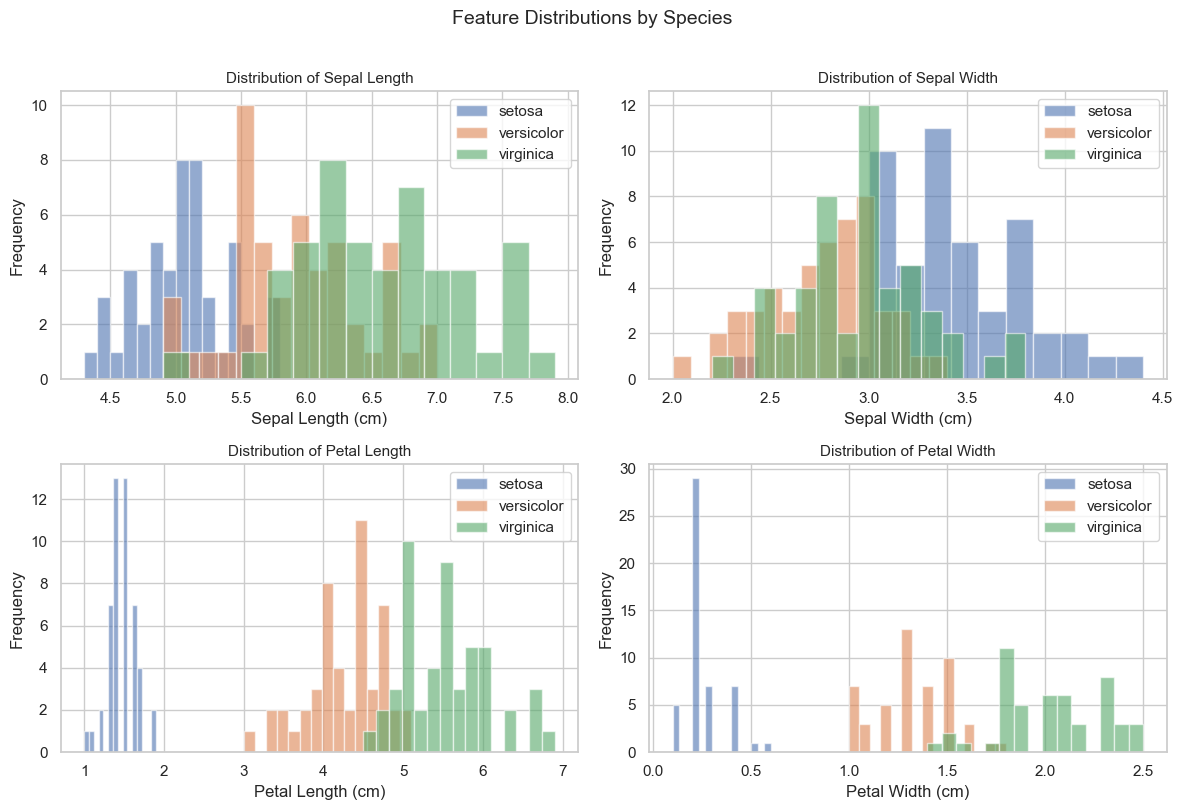

Observation: Petal features show bimodal distributions, clearly separating setosa from others.


In [7]:
# Histogram for all numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['steelblue', 'coral', 'green', 'purple']

for ax, feature, color in zip(axes.flatten(), features, colors):
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        ax.hist(subset, bins=15, alpha=0.6, label=species)
    ax.set_title(f'Distribution of {feature.replace("_", " ").title()}', fontsize=11)
    ax.set_xlabel(feature.replace("_", " ").title() + " (cm)")
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Species', fontsize=14, y=1.01)
plt.tight_layout()

plt.show()
print("Observation: Petal features show bimodal distributions, clearly separating setosa from others.")


### Box Plot – Outliers and Spread

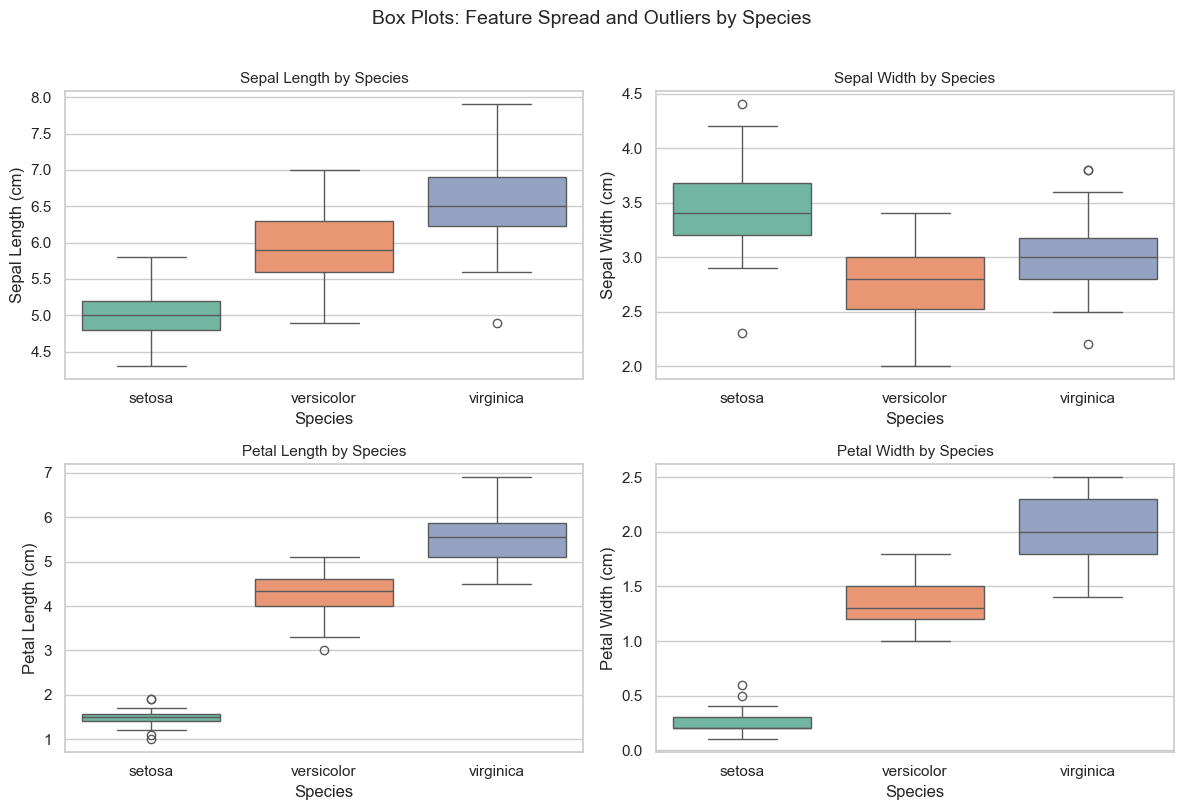

Observation: Setosa has notably smaller petals. A few outliers visible in sepal width.


In [8]:
# Box plots for all features grouped by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feature, hue='species', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{feature.replace("_", " ").title()} by Species', fontsize=11)
    ax.set_xlabel('Species')
    ax.set_ylabel(feature.replace("_", " ").title() + " (cm)")

plt.suptitle('Box Plots: Feature Spread and Outliers by Species', fontsize=14, y=1.01)
plt.tight_layout()

plt.show()
print("Observation: Setosa has notably smaller petals. A few outliers visible in sepal width.")

### Correlation Heatmap

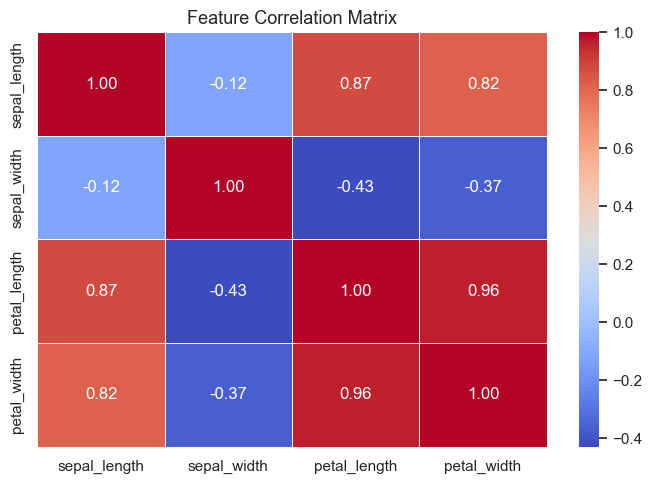

Observation: Petal length and petal width are highly correlated (0.96).


In [9]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()
print("Observation: Petal length and petal width are highly correlated (0.96).")


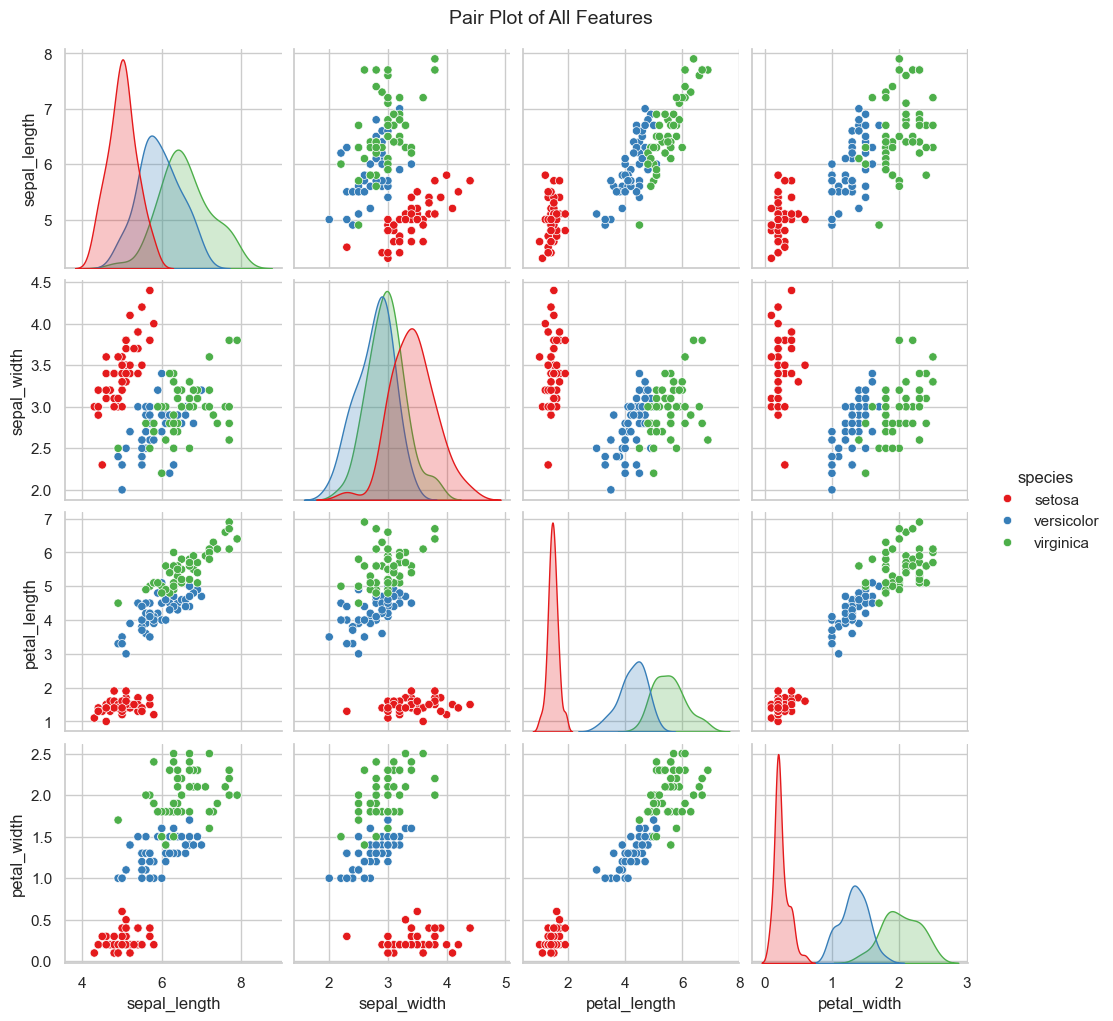

Observation: Petal features are the best for separating the three species.


In [10]:
# Pair plot for all feature combinations
pairplot = sns.pairplot(df, hue='species', palette='Set1', diag_kind='kde', height=2.5)
pairplot.fig.suptitle('Pair Plot of All Features', y=1.02, fontsize=14)

plt.show()
print("Observation: Petal features are the best for separating the three species.")


## 3. Conclusion

### Key Insights:
1. **Setosa is easily separable** from the other two species using petal dimensions.
2. **Versicolor and Virginica** overlap slightly but are still distinguishable.
3. **Petal length & width** are highly correlated (r = 0.96) and are the most discriminative features.
4. **No missing values** were found in the dataset – it's clean and ready for modeling.
5. **Sepal width** has a few outliers particularly in the setosa class.

### What We Learned:
- How to load and inspect a dataset using `pandas`
- How to create scatter plots, histograms, box plots, and heatmaps using `matplotlib` and `seaborn`
- The importance of visual exploration before building machine learning models
